In [9]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

In [10]:
# STEP 1: DEFINE JOB SITES
# ------------------------------------------------------------
# Time windows are in minutes from 8:00am (start of working day)
# e.g. (0, 60)   = must arrive between 8:00am and 9:00am
#      (60, 180)  = must arrive between 9:00am and 11:00am
#      (0, 480)   = open all day (8:00am to 4:00pm)

LOCATIONS = {
    "names": [
        "Depot (HQ)",   # 0
        "Site A",       # 1
        "Site B",       # 2
        "Site C",       # 3
        "Site D",       # 4
        "Site E",       # 5
        "Site F",       # 6
        "Site G",       # 7
        "Site H",       # 8
        "Site I",       # 9
        "Site J",       # 10
    ],
    "coordinates": [
        (5, 5),    # 0 Depot
        (2, 9),    # 1 Site A
        (8, 9),    # 2 Site B
        (1, 6),    # 3 Site C
        (9, 6),    # 4 Site D
        (3, 3),    # 5 Site E
        (7, 3),    # 6 Site F
        (4, 7),    # 7 Site G
        (6, 7),    # 8 Site H
        (4, 4),    # 9 Site I
        (6, 4),    # 10 Site J
    ],
    "demands": [0, 2, 4, 3, 5, 2, 4, 3, 2, 4, 3],

    # (earliest_arrival, latest_arrival) in minutes from 8:00am
    "time_windows": [
        (0,   480),   # 0  Depot      — open all day from 8am to 4 pm
        (0,   120),   # 1  Site A     — must arrive by 10:00am
        (60,  240),   # 2  Site B     — 9:00am to 12:00pm
        (0,   120),   # 3  Site C     — must arrive by 10:00am
        (120, 300),   # 4  Site D     — 10:00am to 1:00pm
        (60,  240),   # 5  Site E     — 9:00am to 12:00pm
        (180, 360),   # 6  Site F     — 11:00am to 2:00pm
        (0,   180),   # 7  Site G     — must arrive by 11:00am
        (120, 300),   # 8  Site H     — 10:00am to 1:00pm
        (240, 420),   # 9  Site I     — 12:00pm to 3:00pm
        (300, 480),   # 10 Site J     — 1:00pm to 4:00pm
    ],

    # How long the vehicle stays at each site (minutes)
    "service_times": [0, 30, 45, 30, 60, 30, 45, 30, 30, 45, 30],
    # 0 = depot (no service time)
    # 30 = 30 minutes on site (e.g. crew setup + inspection)
    # 60 = 1 hour (larger jobs)
}



In [11]:
# STEP 2: COMPUTE DISTANCE AND TIME MATRICES
# ------------------------------------------------------------
def compute_distance_matrix(coordinates):
    """Euclidean distance between all node pairs (scaled x100)."""
    n = len(coordinates)
    matrix = []
    for i in range(n):
        row = []
        for j in range(n):
            x1, y1 = coordinates[i]
            x2, y2 = coordinates[j]
            dist = math.hypot(x2 - x1, y2 - y1) *100
            row.append(int(dist))
        matrix.append(row)
    return matrix


def compute_time_matrix(coordinates, speed=1.0):
    """
    Travel time between all node pairs in minutes.
    Speed is in coordinate-units per minute.
    At speed=1.0, travelling distance 3.0 units takes 3 minutes.
    """
    n = len(coordinates)
    matrix = []
    for i in range(n):
        row = []
        for j in range(n):
            x1, y1 = coordinates[i]
            x2, y2 = coordinates[j]
            travel_time = math.hypot(x2 - x1, y2 - y1) / speed
            row.append(int(travel_time))
        matrix.append(row)
    return matrix

In [12]:
def create_data_model():
    data = {}
    data["coordinates"]      = LOCATIONS["coordinates"]
    data["names"]            = LOCATIONS["names"]
    data["demands"]          = LOCATIONS["demands"]
    data["time_windows"]     = LOCATIONS["time_windows"]
    data["service_times"]    = LOCATIONS["service_times"]
    data["distance_matrix"]  = compute_distance_matrix(data["coordinates"])
    data["time_matrix"]      = compute_time_matrix(data["coordinates"])
    data["vehicle_capacities"] = [14, 14, 14]
    data["num_vehicles"]     = 3
    data["depot"]            = 0
    data["max_time"]         = 480   # working day = 480 minutes (8hrs)
    return data


In [13]:
# STEP 4: EXTRACT ROUTES FROM SOLUTION
# ------------------------------------------------------------
def extract_routes(data, manager, routing, solution, time_dimension):
    """
    Walks through the OR-Tools solution for each vehicle.
    Now also captures the arrival time at each stop.
    """
    routes = []
    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route_nodes    = []
        route_arrivals = []   # NEW: arrival time at each stop
        route_distance = 0
        route_load     = 0

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route_nodes.append(node)
            route_load += data["demands"][node]

            # NEW: read the arrival time from the time dimension
            time_var = time_dimension.CumulVar(index)
            arrival  = solution.Min(time_var)   # earliest feasible arrival
            route_arrivals.append(arrival)

            prev  = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(
                prev, index, vehicle_id
            )

        route_nodes.append(0)
        time_var = time_dimension.CumulVar(index)
        route_arrivals.append(solution.Min(time_var))  # depot return time

        routes.append({
            "vehicle_id":  vehicle_id,
            "nodes":       route_nodes,
            "arrivals":    route_arrivals,
            "distance":    route_distance,
            "load":        route_load,
            "capacity":    data["vehicle_capacities"][vehicle_id],
        })
    return routes


In [14]:
# STEP 8: SOLVE THE VRPTW
# ------------------------------------------------------------
data = create_data_model()

manager = pywrapcp.RoutingIndexManager(
    len(data["time_matrix"]),
    data["num_vehicles"],
    data["depot"]
)

routing = pywrapcp.RoutingModel(manager)


In [16]:
compute_time_matrix(data['coordinates'])

[[0, 5, 5, 4, 4, 2, 2, 2, 2, 1, 1],
 [5, 0, 6, 3, 7, 6, 7, 2, 4, 5, 6],
 [5, 6, 0, 7, 3, 7, 6, 4, 2, 6, 5],
 [4, 3, 7, 0, 8, 3, 6, 3, 5, 3, 5],
 [4, 7, 3, 8, 0, 6, 3, 5, 3, 5, 3],
 [2, 6, 7, 3, 6, 0, 4, 4, 5, 1, 3],
 [2, 7, 6, 6, 3, 4, 0, 5, 4, 3, 1],
 [2, 2, 4, 3, 5, 4, 5, 0, 2, 3, 3],
 [2, 4, 2, 5, 3, 5, 4, 2, 0, 3, 3],
 [1, 5, 6, 3, 5, 1, 3, 3, 3, 0, 2],
 [1, 6, 5, 5, 3, 3, 1, 3, 3, 2, 0]]

In [32]:
# STEP 5: HELPER — convert minutes to clock time string
# ------------------------------------------------------------
def mins_to_clock(minutes):
    """Converts minutes from 8:00am to a clock time string."""
    total = 8 * 60 + minutes   # shift to real clock time
    h = total // 60
    m = total % 60
    return f"{h:02d}:{m:02d}"


In [33]:
# STEP 6: PRINT SOLUTION
# ------------------------------------------------------------
def print_solution(data, routes):
    print("\n" + "="*60)
    print("  VRPTW SOLUTION")
    print("="*60)
    total_distance = 0

    for r in routes:
        print(f"\n  Vehicle {r['vehicle_id'] + 1}:")
        for idx, node in enumerate(r["nodes"]):
            arrival = r["arrivals"][idx]
            window  = data["time_windows"][node]
            name    = data["names"][node]
            clock   = mins_to_clock(arrival)
            window_str = f"(window: {mins_to_clock(window[0])} - {mins_to_clock(window[1])})"
            print(f"     {name:15s}  arrive: {clock}  {window_str}")

        print(f"     ---")
        print(f"     Distance : {r['distance'] / 100:.2f} units")
        print(f"     Load     : {r['load']} / {r['capacity']} units")
        total_distance += r["distance"]

    print("\n" + "-"*60)
    print(f"  Total distance: {total_distance / 100:.2f} units")
    print("="*60 + "\n")



In [34]:
# STEP 7: VISUALIZE ROUTES WITH TIME WINDOWS
# ------------------------------------------------------------
def visualize_routes(data, routes):
    """
    Plots routes on a 2D map.
    Each site label now shows its time window.
    """
    fig, ax = plt.subplots(figsize=(10, 9))
    colors  = ["#2196F3", "#FF5722", "#4CAF50"]
    coords  = data["coordinates"]

    # Draw route arrows
    for r in routes:
        color = colors[r["vehicle_id"]]
        nodes = r["nodes"]
        for i in range(len(nodes) - 1):
            x1, y1 = coords[nodes[i]]
            x2, y2 = coords[nodes[i + 1]]
            ax.annotate(
                "",
                xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=2.0,
                    connectionstyle="arc3,rad=0.07"
                )
            )

    # Draw depot
    dx, dy = coords[0]
    ax.plot(dx, dy, marker="*", markersize=20,
            color="#FFD700", markeredgecolor="#555", zorder=5)
    ax.annotate("Depot (HQ)", (dx, dy),
                textcoords="offset points", xytext=(8, 8),
                fontsize=9, fontweight="bold")

    # Draw job sites with time window labels
    for i in range(1, len(coords)):
        x, y   = coords[i]
        tw     = data["time_windows"][i]
        window = f"{mins_to_clock(tw[0])}-{mins_to_clock(tw[1])}"

        ax.plot(x, y, "o", markersize=16, color="white",
                markeredgecolor="#555", markeredgewidth=1.5, zorder=4)
        ax.text(x, y, str(data["demands"][i]),
                ha="center", va="center",
                fontsize=8, fontweight="bold", color="#333", zorder=5)
        ax.annotate(
            f"{data['names'][i]}\n{window}",
            (x, y),
            textcoords="offset points", xytext=(10, 6),
            fontsize=7.5, color="#444",
            bbox=dict(boxstyle="round,pad=0.2",
                      fc="white", ec="#ccc", alpha=0.8)
        )

    # Legend
    legend_handles = [
        mpatches.Patch(
            color=colors[r["vehicle_id"]],
            label=(f"Vehicle {r['vehicle_id']+1}  |  "
                   f"load: {r['load']}/{r['capacity']}  |  "
                   f"dist: {r['distance']/100:.1f}")
        )
        for r in routes
    ]
    ax.legend(handles=legend_handles, loc="lower right",
              fontsize=9, framealpha=0.9)

    ax.set_title(
        "VRPTW Route Map — Engineering Fleet\n"
        "(circle numbers = demand  |  labels show time windows)",
        fontsize=12, pad=14
    )
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 11)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.savefig("vrptw_routes.png", dpi=150, bbox_inches="tight")
    print("  Route map saved as: vrptw_routes.png\n")
    plt.show()

In [35]:
 # --- Distance callback 
def distance_callback(from_index, to_index):
    return data["distance_matrix"][manager.IndexToNode(from_index)][manager.IndexToNode(to_index)]

transit_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_index)

In [36]:
    # --- Capacity constraint 
def demand_callback(from_index):
    return data["demands"][manager.IndexToNode(from_index)]

demand_index = routing.RegisterUnaryTransitCallback(demand_callback)
    
routing.AddDimensionWithVehicleCapacity(
        demand_index, 
        0,
        data["vehicle_capacities"],
        True, "Capacity"
)


True

In [37]:
    # --- NEW: Time callback ---
    # Returns travel time + service time for each arc
    # This is what OR-Tools uses to track where vehicles are in time
def time_callback(from_index, to_index):
    from_node    = manager.IndexToNode(from_index)
    to_node      = manager.IndexToNode(to_index)
    travel_time  = data["time_matrix"][from_node][to_node]
    service_time = data["service_times"][from_node]
    return travel_time + service_time

time_index = routing.RegisterTransitCallback(time_callback) 

    # --- NEW: Add Time Dimension ---
    # This tells OR-Tools to track cumulative time for each vehicle
routing.AddDimension(
    time_index,
    60,                   # waiting slack — vehicle can wait up to 60 mins
    data["max_time"],     # maximum total time per vehicle (480 mins = 8hrs)
    False,                # do NOT force start at time zero (vehicles can leave late)
    "Time"
    )
time_dimension = routing.GetDimensionOrDie("Time")

In [38]:
    # --- NEW: Apply time windows to each node ---
    # CumulVar = the time tracker for a node
    # SetRange = enforces earliest and latest arrival
for node in range(len(data["time_windows"])):
    index = manager.NodeToIndex(node)
    time_dimension.CumulVar(index).SetRange(
        data["time_windows"][node][0],   # earliest arrival
        data["time_windows"][node][1]    # latest arrival
    )


In [39]:
    # --- Search strategy ---
search_params = pywrapcp.DefaultRoutingSearchParameters()
search_params.first_solution_strategy = (
    routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
)
    
search_params.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
)

search_params.time_limit.seconds = 5  

Solving VRPTW...

  VRPTW SOLUTION

  Vehicle 1:
     Depot (HQ)       arrive: 08:58  (window: 08:00 - 16:00)
     Site H           arrive: 10:00  (window: 10:00 - 13:00)
     Site B           arrive: 10:32  (window: 09:00 - 12:00)
     Site D           arrive: 11:20  (window: 10:00 - 13:00)
     Depot (HQ)       arrive: 12:24  (window: 08:00 - 16:00)
     ---
     Distance : 12.33 units
     Load     : 11 / 14 units

  Vehicle 2:
     Depot (HQ)       arrive: 11:59  (window: 08:00 - 16:00)
     Site J           arrive: 13:00  (window: 13:00 - 16:00)
     Site F           arrive: 13:31  (window: 11:00 - 14:00)
     Depot (HQ)       arrive: 14:18  (window: 08:00 - 16:00)
     ---
     Distance : 5.64 units
     Load     : 7 / 14 units

  Vehicle 3:
     Depot (HQ)       arrive: 08:00  (window: 08:00 - 16:00)
     Site G           arrive: 08:02  (window: 08:00 - 11:00)
     Site A           arrive: 08:34  (window: 08:00 - 10:00)
     Site C           arrive: 09:07  (window: 08:00 - 10:00

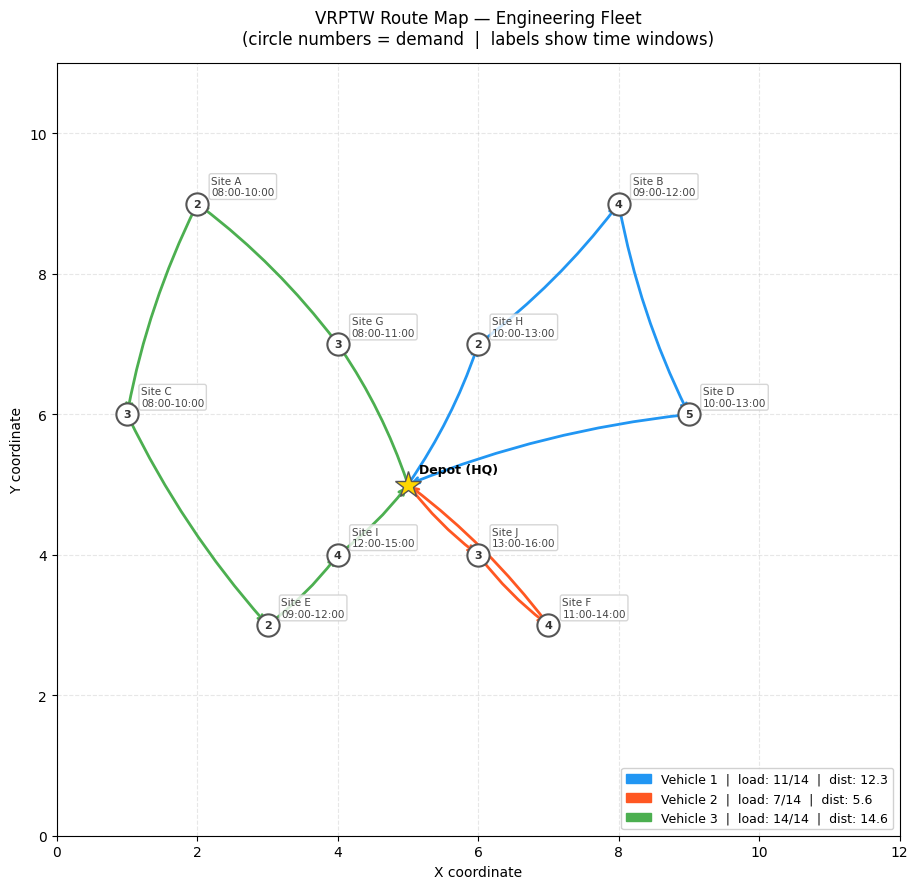

In [40]:
print("Solving VRPTW...")
solution = routing.SolveWithParameters(search_params)

if solution:
    routes = extract_routes(data, manager, routing, solution, time_dimension)
    print_solution(data, routes)
    visualize_routes(data, routes)
else:
    print("No solution found.")
    print("Try: widening time windows, increasing max_time, or reducing demands.")